# EXPERIMENT - 4

Dataset Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

===== INITIAL KNN RESULTS =====
Accuracy: 0.8341463414634146

Confusion Matrix:
 [[79 23]
 [11 92]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro av

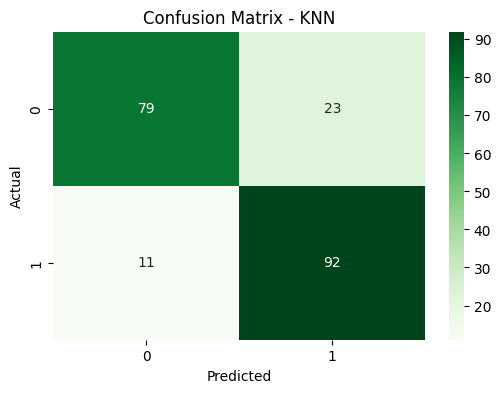


===== HYPERPARAMETER TUNING =====
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 28, 'weights': 'distance'}
Best Cross Validation Score: 0.9853658536585366

===== TUNED KNN RESULTS =====
Accuracy: 1.0


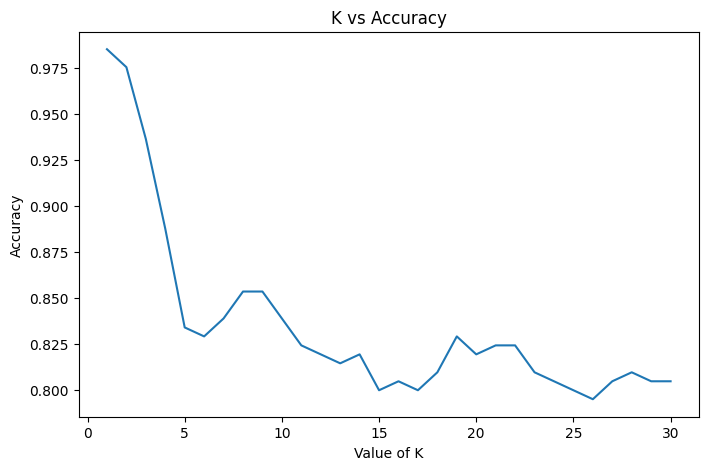

In [2]:
# ============================================================
# EXP 4: KNN with Full Process + Evaluation + Tuning
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# STEP 1: Load Dataset
# ------------------------------------------------------------
df = pd.read_csv("/content/sample_data/heart.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ------------------------------------------------------------
# STEP 2: Define Features and Target
# ------------------------------------------------------------
X = df.drop("target", axis=1)
y = df["target"]

# ------------------------------------------------------------
# STEP 3: Feature Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# STEP 4: Train-Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# STEP 5: Train Initial KNN Model
# ------------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("\n===== INITIAL KNN RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------------------------------------------------
# Confusion Matrix Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------------------------------------------------
# STEP 6: Hyperparameter Tuning
# ------------------------------------------------------------
param_grid = {
    "n_neighbors": range(1, 31),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("\n===== HYPERPARAMETER TUNING =====")
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# ------------------------------------------------------------
# STEP 7: Evaluate Tuned Model
# ------------------------------------------------------------
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test)

print("\n===== TUNED KNN RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_best))

# ------------------------------------------------------------
# STEP 8: K vs Accuracy Graph
# ------------------------------------------------------------
k_range = range(1, 31)
accuracy_scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8,5))
plt.plot(k_range, accuracy_scores)
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

# Example

Manual Distance Calculation:

Distance from [2 4] = 5.00
Distance from [4 6] = 2.24
Distance from [3 5] = 3.61
Distance from [ 8 10] = 3.61
Distance from [9 8] = 3.16
Distance from [10  9] = 4.47

Sorted Indices (Nearest First): [1 4 3 2 5 0]
Nearest Neighbors Index: [1 4 3]
Nearest Neighbor Classes: [0 1 1]

Manual KNN Prediction: 1
Sklearn KNN Prediction: 1


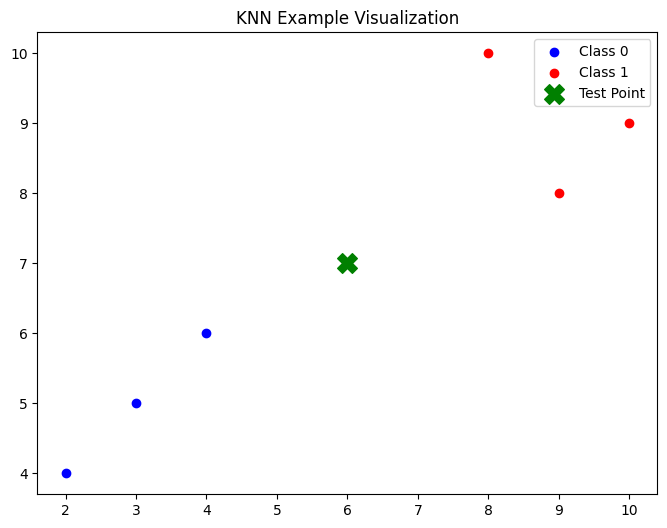

In [3]:
# ==============================================
# KNN Example Implementation (Concept + Graph)
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# ----------------------------------------------
# STEP 1: Create Simple Dataset (2D)
# ----------------------------------------------
X = np.array([
    [2, 4],
    [4, 6],
    [3, 5],
    [8, 10],
    [9, 8],
    [10, 9]
])

y = np.array([0, 0, 0, 1, 1, 1])

# ----------------------------------------------
# STEP 2: New Test Point
# ----------------------------------------------
test_point = np.array([[6, 7]])

# ----------------------------------------------
# STEP 3: Manual Distance Calculation
# ----------------------------------------------
print("Manual Distance Calculation:\n")

distances = []

for point in X:
    distance = np.sqrt(np.sum((point - test_point)**2))
    distances.append(distance)
    print(f"Distance from {point} = {distance:.2f}")

# ----------------------------------------------
# STEP 4: Sort Distances
# ----------------------------------------------
sorted_indices = np.argsort(distances)
print("\nSorted Indices (Nearest First):", sorted_indices)

# Choose K
k = 3
nearest_indices = sorted_indices[:k]
print("Nearest Neighbors Index:", nearest_indices)

nearest_labels = y[nearest_indices]
print("Nearest Neighbor Classes:", nearest_labels)

# Majority Voting
prediction_manual = np.bincount(nearest_labels).argmax()
print("\nManual KNN Prediction:", prediction_manual)

# ----------------------------------------------
# STEP 5: Using sklearn KNN
# ----------------------------------------------
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

prediction_sklearn = knn.predict(test_point)
print("Sklearn KNN Prediction:", prediction_sklearn[0])

# ----------------------------------------------
# STEP 6: Visualization
# ----------------------------------------------
plt.figure(figsize=(8,6))

# Plot class 0
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='blue', label='Class 0')

# Plot class 1
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='red', label='Class 1')

# Plot test point
plt.scatter(test_point[0][0], test_point[0][1],
            color='green', s=200, marker='X', label='Test Point')

plt.title("KNN Example Visualization")
plt.legend()
plt.show()